<a href="https://colab.research.google.com/github/zaima-sohail/Deep_learning_projects/blob/main/RNN_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np

In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.layers import Dense,Flatten,SimpleRNN,Embedding

In [5]:
(X_trian,y_train),(X_test,y_test)=imdb.load_data()

In [7]:
X_trian.shape

(25000,)

In [10]:
X_train=tf.keras.preprocessing.sequence.pad_sequences(X_trian,maxlen=50)
X_test=tf.keras.preprocessing.sequence.pad_sequences(X_test,maxlen=50)

In [11]:
X_train.shape

(25000, 50)

In [13]:
from tensorflow.keras.models import Sequential

In [16]:
model=Sequential()
model.add(SimpleRNN(32,input_shape=(50,1),return_sequences=False))
model.add(Dense(1,activation='sigmoid'))

In [17]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
histroy=model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.5023 - loss: 0.6927 - val_accuracy: 0.5060 - val_loss: 0.6933
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5087 - loss: 0.6924 - val_accuracy: 0.5064 - val_loss: 0.6987
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5090 - loss: 0.6925 - val_accuracy: 0.5053 - val_loss: 0.6937
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5078 - loss: 0.6925 - val_accuracy: 0.5064 - val_loss: 0.6941
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5108 - loss: 0.6924 - val_accuracy: 0.5058 - val_loss: 0.6932
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5101 - loss: 0.6924 - val_accuracy: 0.5054 - val_loss: 0.6935
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5097 - loss: 0.6925 - val_accuracy: 0.5076 - val_loss: 0.6924
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5036 - loss: 0.6925 - val_accuracy: 

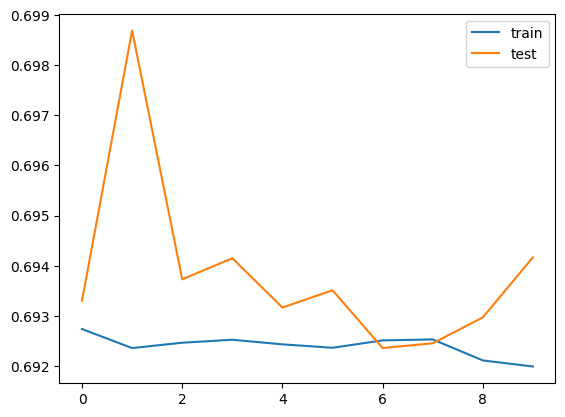

In [21]:
import matplotlib.pyplot as plt
plt.plot(histroy.history['loss'],label='train')
plt.plot(histroy.history['val_loss'],label='test')
plt.legend()
plt.show()